# Step-by-Step Convolutional Neural Network
## Classifying Arctic Sea Ice from Satellite Imagery

**EARTHLAB 2026** — Tuesday Afternoon Practical (Alice Cicirello)

**Instructor:** Alice Cicirello

**Developed by:** Francesco Muschitiello
**Last updated by:** Alice Cicirello (13/06/2026)

---

### What are we doing?

In this practical, we will build a **Convolutional Neural Network (CNN)** from scratch using **PyTorch** to classify Arctic sea ice conditions from satellite imagery.

INPUT DATA: 128×128 grayscale images where pixel intensity represents ice concentration (0 = open water, 255 = full ice), our CNN will learn to classify it into one of three categories:

| Class | Description | Visual Appearance |
|-------|-------------|-------------------|
| **ice** | Consolidated pack ice | Bright white, uniform high intensity |
| **miz** | Marginal ice zone | Mottled gray, mixed textures — the hardest class! |
| **open_water** | Ice-free ocean | Uniform dark/black |

The **marginal ice zone (MIZ)** is the transition region between open ocean and solid pack ice. It is one of the most dynamic and scientifically important regions of the Arctic — and also the hardest to classify, because it contains a complex mixture of ice floes, broken ice, and open water.

### Why use CNNs for this?

In the morning practical, we used a standard ANN (fully connected network) for tabular data. But images are fundamentally different from tables:
- **Spatial structure matters**: neighbouring pixels are related to each other
- **Local patterns are important**: edges, textures, and gradients carry meaning
- **Translation invariance**: an ice floe looks the same whether it appears in the top-left or bottom-right of the image

Standard ANNs would treat each pixel as an independent input feature — throwing away all the spatial information. A **Convolutional Neural Network** preserves spatial relationships by using small sliding filters that detect local patterns like edges, textures, and shapes.

Re-check L3: Convolutional Neural Network architectures for image analysis
### What you will learn

1. How to load image data using PyTorch's `ImageFolder` and `DataLoader`
2. How convolutional layers, pooling layers, and fully connected layers work together
3. How to build, train, and evaluate a CNN for image classification
4. How to interpret what a CNN has learned by visualising its filters and feature maps
5. How to detect **distribution shift** — when a model trained on one time period fails on another

Let's get started!

---
## 1. Import Libraries

We need several libraries:
- **PyTorch** (`torch`, `torch.nn`, `torch.optim`): our deep learning framework
- **torchvision** (`datasets`, `transforms`): utilities for loading and transforming image data
- **matplotlib**: for plotting images and training curves
- **numpy**: for numerical operations
- **scikit-learn**: for the confusion matrix

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# For reproducibility — setting seeds so everyone gets the same results
torch.manual_seed(42)
np.random.seed(42)

# Check if a GPU is available (useful but not required)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


---
## 2. Load the Data

Our dataset is organised in **ImageFolder** format — a standard layout that PyTorch can read automatically:

```
sea_ice_dataset/
    train/
        ice/          (1600 images)
        miz/          (1600 images)
        open_water/   (1600 images)
    test/
        ice/          (400 images)
        miz/          (400 images)
        open_water/   (400 images)
    test_2019/
        ice/          (600 images)
        miz/          (600 images)
        open_water/   (600 images)
    test_2024/
        ice/          (600 images)
        miz/          (600 images)
        open_water/   (600 images)
```

Each subfolder name becomes a class label. PyTorch assigns integer labels alphabetically: `ice` = 0, `miz` = 1, `open_water` = 2.

### Transforms

Before feeding images to the network, we apply **transforms** — a pipeline of preprocessing steps:

1. **`Grayscale(num_output_channels=1)`**: Ensures images are loaded as single-channel grayscale (they already are, but this makes it explicit)
2. **`ToTensor()`**: Converts the image from a PIL Image (pixel values 0–255) to a PyTorch tensor (values 0.0–1.0). Also rearranges dimensions from (H, W, C) to (C, H, W), which is what PyTorch expects.
3. **`Normalize(mean=[0.5], std=[0.5])`**: Scales pixel values from [0, 1] to [-1, 1]. This centres the data around zero, which helps training convergence. The formula is: `pixel = (pixel - mean) / std`

In [2]:
# Path to the dataset (relative to this notebook's location)
data_dir = '../data/sea_ice_dataset/'

# Define the image transforms
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# Load full datasets
train_full = datasets.ImageFolder(data_dir + 'train', transform=transform)
test_dataset = datasets.ImageFolder(data_dir + 'test', transform=transform)

class_names = train_full.classes
n_classes = len(class_names)

# --- KEY TEACHING POINT ---
# We deliberately use only a SMALL subset of training data (30 images per class).
# With 4800 training images the task is trivially easy — even a simple model gets 100%.
# Restricting to 90 images forces the model to actually learn and makes errors visible.
# This is also a realistic scenario: in many research settings, labelled data is scarce.

from torch.utils.data import Subset

n_per_class = 30  # Try changing this! 30, 100, 500, 1600 (full)
np.random.seed(42)

# Select n_per_class random indices for each class
subset_indices = []
targets = np.array(train_full.targets)
for class_idx in range(n_classes):
    class_indices = np.where(targets == class_idx)[0]
    chosen = np.random.choice(class_indices, size=n_per_class, replace=False)
    subset_indices.extend(chosen)

train_dataset = Subset(train_full, subset_indices)

print(f"Classes: {class_names}")
print(f"Training images: {len(train_dataset)}  (subsampled from {len(train_full)})")
print(f"  — {n_per_class} per class")
print(f"Test images:     {len(test_dataset)}")
print(f"Image size:      128 x 128 grayscale")

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"\nTrain batches: {len(train_loader)},  Test batches: {len(test_loader)}")
print(f"\nTip: change n_per_class above and re-run to see how dataset size affects accuracy!")


Classes: ['ice', 'miz', 'open_water']
Training images: 90  (subsampled from 4800)
  — 30 per class
Test images:     1200
Image size:      128 x 128 grayscale

Train batches: 3,  Test batches: 19

Tip: change n_per_class above and re-run to see how dataset size affects accuracy!


---
## 3. Visualise the Training Data

Before building a model, we should always look at the data. This helps us understand what the network will see and gives us intuition about which classes might be hard to distinguish.

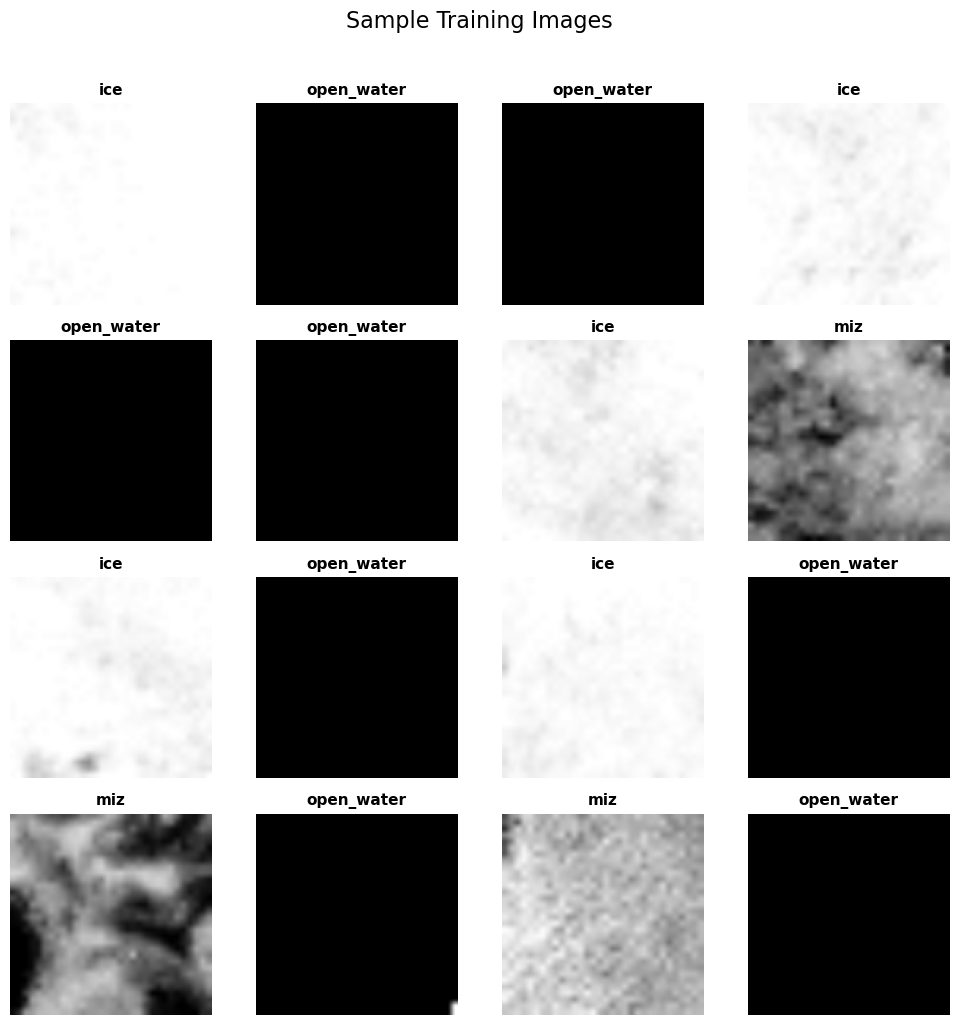


Class distribution in training set:
  ice: 30 images
  miz: 30 images
  open_water: 30 images


In [3]:
# Get a batch of training images
images, labels = next(iter(train_loader))

# Plot a 4x4 grid of training images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle('Sample Training Images', fontsize=16, y=1.02)

for i, ax in enumerate(axes.flat):
    if i < len(images):
        # Undo normalisation for display: pixel = pixel * std + mean
        img = images[i].squeeze() * 0.5 + 0.5  # Back to [0, 1]
        ax.imshow(img, cmap='gray', vmin=0, vmax=1)
        ax.set_title(class_names[labels[i]], fontsize=11, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

# Also show class distribution
print("\nClass distribution in training set:")
for i, name in enumerate(class_names):
    count = sum(1 for _, label in train_dataset if label == i)
    print(f"  {name}: {count} images")

---
## 4. CNN Building Blocks — What Makes CNNs Special?

Before writing any code, let's understand the three key building blocks of a CNN. If you are coming from a non-CS background, think of it this way:

### Convolutional layers — Feature detectors

A **convolutional layer** slides a small filter (e.g., 3×3 pixels) across the image and computes a dot product at each position. Each filter learns to detect a specific local pattern:
- Early filters detect **simple features**: edges, gradients, spots
- Later filters combine these into **complex features**: textures, shapes, object parts

**Key idea**: the same filter is applied everywhere in the image. This means the network can detect an ice edge regardless of where it appears — this is called **translation invariance**.

The output of a convolutional layer is a **feature map** — a 2D map showing where in the image a particular pattern was detected.

### Pooling layers — Downsampling

**Max pooling** shrinks the feature maps by keeping only the strongest activation in each small region (e.g., 2×2). This does two things:
1. **Reduces computation**: fewer pixels to process in subsequent layers
2. **Adds robustness**: small shifts in the input don't change the output much

### Fully connected layers — Classification

After several rounds of convolution and pooling, we flatten the feature maps into a 1D vector and pass it through standard fully connected layers (like the ANN from this morning). These layers combine the detected features to make the final classification decision.

### The full pipeline

```
Input Image (1×128×128)
    ↓
[Conv → ReLU → Pool] × 3    ← Feature extraction
    ↓
Flatten
    ↓
[Linear → ReLU] → Linear    ← Classification
    ↓
Class Scores (3 values)
```

## 6. Define the CNN Architecture

We **start with a deliberately simple model**: just one convolutional layer with 8 filters, followed by a single fully connected layer. This is intentionally underpowered.

**Why start simple?**
- We can see where the model struggles (which classes does it confuse?)
- It gives us a baseline to improve upon
- Adding layers and watching accuracy climb teaches more than a model that gets 100% on the first try

**Our minimal architecture:**
- `Conv2d(1, 8, 3)` → 8 filters scanning for basic patterns (edges, brightness)
- `MaxPool2d(2)` → halve spatial dimensions (128→64)
- `Flatten` → reshape to a vector
- `Linear(32768, 3)` → classify into 3 classes

After evaluating this baseline, we will discuss what to add (more layers, more filters, dropout) and you can experiment with improvements.

In [4]:
# A deliberately SIMPLE CNN — just one convolutional layer with very few filters.
# We start weak on purpose: this lets us see where the model struggles,
# and later we can add complexity and watch accuracy improve.

class SeaIceCNN(nn.Module):
    """Minimal CNN: 1 conv layer, 4 filters, no hidden FC layer."""
    def __init__(self, num_classes=3):
        super().__init__()
        # Single conv layer: 1 input channel, only 4 filters, 3x3 kernel
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(4, 4)  # Aggressive pooling: 128 -> 32
        self.relu = nn.ReLU()
        
        # After conv(128x128) -> pool(32x32): 4 channels x 32 x 32 = 4096
        self.fc1 = nn.Linear(4 * 32 * 32, num_classes)
    
    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))   # [B, 4, 32, 32]
        x = x.view(x.size(0), -1)                  # flatten
        x = self.fc1(x)                             # [B, 3]
        return x

model = SeaIceCNN(num_classes=3).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model architecture:\n{model}")
print(f"\nTotal parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"\nNote: This is intentionally simple! Only 4 filters and aggressive pooling.")
print(f"We will discuss how to improve it after seeing where it fails.")


Model architecture:
SeaIceCNN(
  (conv1): Conv2d(1, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (fc1): Linear(in_features=4096, out_features=3, bias=True)
)

Total parameters:     12,331
Trainable parameters: 12,331

Note: This is intentionally simple! Only 4 filters and aggressive pooling.
We will discuss how to improve it after seeing where it fails.


---
## 6. Model Summary and Parameter Count

Let's count how many learnable parameters our CNN has. Each convolutional filter and each fully connected weight is a parameter that the network will learn during training.

In [5]:
# Count the total number of learnable parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print()

# Break down by layer
print("Parameter breakdown by layer:")
print(f"{'Layer':<25s} {'Shape':>20s} {'Parameters':>12s}")
print("-" * 60)
for name, param in model.named_parameters():
    print(f"  {name:<23s} {str(list(param.shape)):>20s} {param.numel():>12,}")

print("-" * 60)
print(f"  {'TOTAL':<23s} {'':>20s} {total_params:>12,}")
print()
print("Notice: most parameters are in the first fully connected layer (fc1).")
print(f"fc1 alone has {64*16*16*128 + 128:,} parameters = {(64*16*16*128 + 128)/total_params*100:.1f}% of total!")

Total parameters:     12,331
Trainable parameters: 12,331

Parameter breakdown by layer:
Layer                                    Shape   Parameters
------------------------------------------------------------
  conv1.weight                    [4, 1, 3, 3]           36
  conv1.bias                               [4]            4
  fc1.weight                         [3, 4096]       12,288
  fc1.bias                                 [3]            3
------------------------------------------------------------
  TOTAL                                              12,331

Notice: most parameters are in the first fully connected layer (fc1).
fc1 alone has 2,097,280 parameters = 17008.2% of total!


---
## 7. Define Loss Function and Optimiser

### Loss function: Cross-Entropy Loss

This morning we used **MSE (Mean Squared Error)** for regression — predicting continuous values. For **classification**, we use **Cross-Entropy Loss** instead.

**Why not MSE for classification?** MSE treats the output as continuous numbers, but classification outputs are probabilities over discrete classes. Cross-Entropy Loss:
- Applies a **softmax** function to convert raw scores into probabilities (values between 0 and 1 that sum to 1)
- Then computes the **negative log-likelihood** of the correct class

This gives a much stronger gradient signal when the model is confidently wrong, which accelerates learning.

### Optimiser: Adam

As in the morning practical, we use **Adam** with a learning rate of 0.001. Adam adapts the learning rate for each parameter individually, which works particularly well for CNNs where different layers may need different update speeds.

In [6]:
# Loss function — CrossEntropyLoss includes softmax internally
criterion = nn.CrossEntropyLoss()

# Optimiser
learning_rate = 0.001
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

print(f"Loss function: CrossEntropyLoss")
print(f"  - For classification (not regression!)")
print(f"  - Includes softmax internally — no need to add it to the model")
print(f"\nOptimiser: Adam (lr={learning_rate})")

Loss function: CrossEntropyLoss
  - For classification (not regression!)
  - Includes softmax internally — no need to add it to the model

Optimiser: Adam (lr=0.001)


---
## 8. Training Loop

The training loop for a CNN is the same structure as for an ANN:

1. **Forward pass**: Feed a batch of images through the network to get class scores
2. **Compute loss**: Measure how far the predicted probabilities are from the true labels
3. **Backward pass (backpropagation)**: Compute gradients of the loss with respect to every weight and filter
4. **Update weights**: The optimiser adjusts all parameters to reduce the loss

We also track **accuracy** (percentage of correctly classified images) on both the training and test sets, which is more interpretable than the raw loss value for classification problems.

In [7]:
# Training configuration
n_epochs = 5

# Lists to store metrics for plotting
train_losses = []
train_accuracies = []
test_accuracies = []

print(f"Training for {n_epochs} epochs...")
print(f"{'Epoch':>6s} | {'Train Loss':>12s} | {'Train Acc':>10s} | {'Test Acc':>10s}")
print("-" * 48)

for epoch in range(n_epochs):
    
    # =====================
    # TRAINING PHASE
    # =====================
    model.train()  # Set model to training mode
    epoch_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for images, labels in train_loader:
        # Move data to device (GPU if available)
        images = images.to(device)
        labels = labels.to(device)
        
        # Step 1: Forward pass — get class scores
        outputs = model(images)
        
        # Step 2: Compute loss
        loss = criterion(outputs, labels)
        
        # Step 3: Backward pass — compute gradients
        optimizer.zero_grad()  # Clear old gradients first!
        loss.backward()        # Compute new gradients
        
        # Step 4: Update weights
        optimizer.step()
        
        # Track metrics
        epoch_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)  # Get class with highest score
        correct_train += (predicted == labels).sum().item()
        total_train += labels.size(0)
    
    avg_train_loss = epoch_loss / total_train
    train_acc = 100.0 * correct_train / total_train
    
    # =====================
    # TEST EVALUATION
    # =====================
    model.eval()  # Set model to evaluation mode
    correct_test = 0
    total_test = 0
    
    with torch.no_grad():  # No gradient computation needed for evaluation
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            correct_test += (predicted == labels).sum().item()
            total_test += labels.size(0)
    
    test_acc = 100.0 * correct_test / total_test
    
    # Store metrics
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    
    # Print progress every epoch
    print(f"{epoch+1:6d} | {avg_train_loss:12.4f} | {train_acc:9.2f}% | {test_acc:9.2f}%")

print("-" * 48)
print(f"Training complete!")

Training for 5 epochs...
 Epoch |   Train Loss |  Train Acc |   Test Acc
------------------------------------------------
     1 |       0.9964 |     45.56% |     67.08%
     2 |       0.4293 |     80.00% |     96.33%
     3 |       0.3188 |     96.67% |     88.33%
     4 |       0.2245 |     93.33% |     87.92%
     5 |       0.1908 |     93.33% |     91.42%
------------------------------------------------
Training complete!


---
## 9. Plot Learning Curves

Let's visualise how training progressed. We look at two things:
- **Loss curve**: Did the loss decrease smoothly? Did it converge?
- **Accuracy curves**: How do training and test accuracy compare? A large gap suggests overfitting.

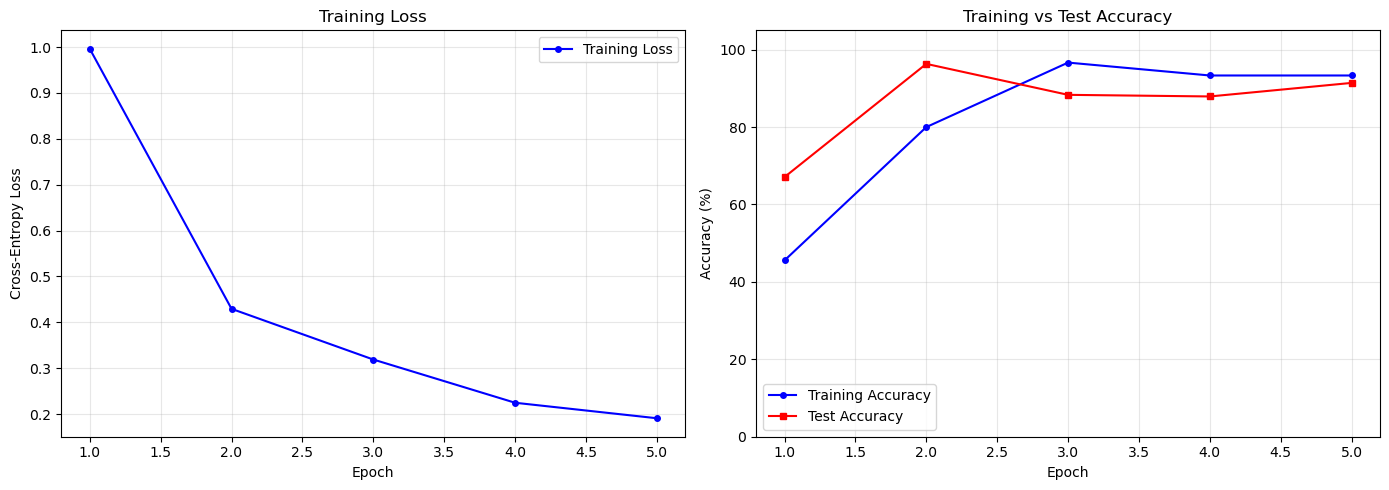


Final training accuracy: 93.33%
Final test accuracy:     91.42%
Gap (train - test):      1.92 percentage points
  -> Small gap: the model generalises well!


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(range(1, n_epochs + 1), train_losses, 'b-o', linewidth=1.5, markersize=4, label='Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curves
axes[1].plot(range(1, n_epochs + 1), train_accuracies, 'b-o', linewidth=1.5, markersize=4, label='Training Accuracy')
axes[1].plot(range(1, n_epochs + 1), test_accuracies, 'r-s', linewidth=1.5, markersize=4, label='Test Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training vs Test Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 105])

plt.tight_layout()
plt.show()

print(f"\nFinal training accuracy: {train_accuracies[-1]:.2f}%")
print(f"Final test accuracy:     {test_accuracies[-1]:.2f}%")
gap = train_accuracies[-1] - test_accuracies[-1]
print(f"Gap (train - test):      {gap:.2f} percentage points")
if gap > 10:
    print("  -> Significant gap: the model may be overfitting.")
elif gap > 5:
    print("  -> Moderate gap: some overfitting, but acceptable for a first model.")
else:
    print("  -> Small gap: the model generalises well!")

---
## 10. Evaluate on the Test Set (2023)

Let's do a thorough evaluation of our model on the test set. We will compute:
- **Overall accuracy**: what fraction of all images were classified correctly
- **Per-class accuracy**: how well the model does on each class individually
- **Confusion matrix**: which classes get confused with which

The confusion matrix is particularly informative — it shows us not just how many errors the model makes, but what *kind* of errors.

In [9]:
def evaluate_model(model, data_loader, class_names, device):
    """
    Evaluate the model on a dataset and return predictions, labels, and metrics.
    """
    model.eval()
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    all_predictions = np.array(all_predictions)
    all_labels = np.array(all_labels)
    
    # Overall accuracy
    overall_acc = 100.0 * (all_predictions == all_labels).sum() / len(all_labels)
    
    # Per-class accuracy
    per_class_acc = {}
    for i, name in enumerate(class_names):
        mask = all_labels == i
        if mask.sum() > 0:
            per_class_acc[name] = 100.0 * (all_predictions[mask] == all_labels[mask]).sum() / mask.sum()
    
    return all_predictions, all_labels, overall_acc, per_class_acc


# Evaluate on test set
test_preds, test_labels, test_acc, test_per_class = evaluate_model(
    model, test_loader, class_names, device
)

print("=" * 50)
print("  TEST SET EVALUATION (2023 data)")
print("=" * 50)
print(f"\n  Overall accuracy: {test_acc:.2f}%")
print(f"\n  Per-class accuracy:")
for name, acc in test_per_class.items():
    marker = " <-- hardest class" if acc == min(test_per_class.values()) else ""
    print(f"    {name:>12s}: {acc:.2f}%{marker}")
print("=" * 50)

  TEST SET EVALUATION (2023 data)

  Overall accuracy: 91.42%

  Per-class accuracy:
             ice: 100.00%
             miz: 74.25% <-- hardest class
      open_water: 100.00%


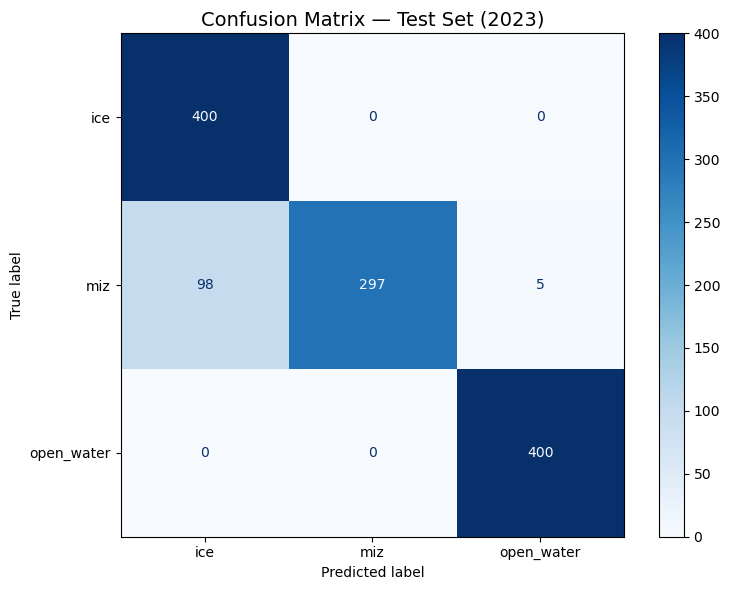


Reading the confusion matrix:
  - Rows = true class, Columns = predicted class
  - Diagonal = correct predictions
  - Off-diagonal = errors

Most common confusion: look at the largest off-diagonal values.
The MIZ class is typically the hardest because it sits between
ice and open water — it has features of both.


In [16]:
# Compute and display confusion matrix
cm = confusion_matrix(test_labels, test_preds)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix — Test Set (2023)', fontsize=14)
plt.tight_layout()
plt.show()

print("\nReading the confusion matrix:")
print("  - Rows = true class, Columns = predicted class")
print("  - Diagonal = correct predictions")
print("  - Off-diagonal = errors")
print(f"\nMost common confusion: look at the largest off-diagonal values.")
print("The MIZ class is typically the hardest because it sits between")
print("ice and open water — it has features of both.")

---
## 11. Visualise Misclassified Examples

Looking at the images the model got wrong gives us insight into what is confusing the network. Are the misclassified images genuinely ambiguous, or is the model making silly mistakes?

Total misclassified: 103 out of 1200
Error rate: 8.58%


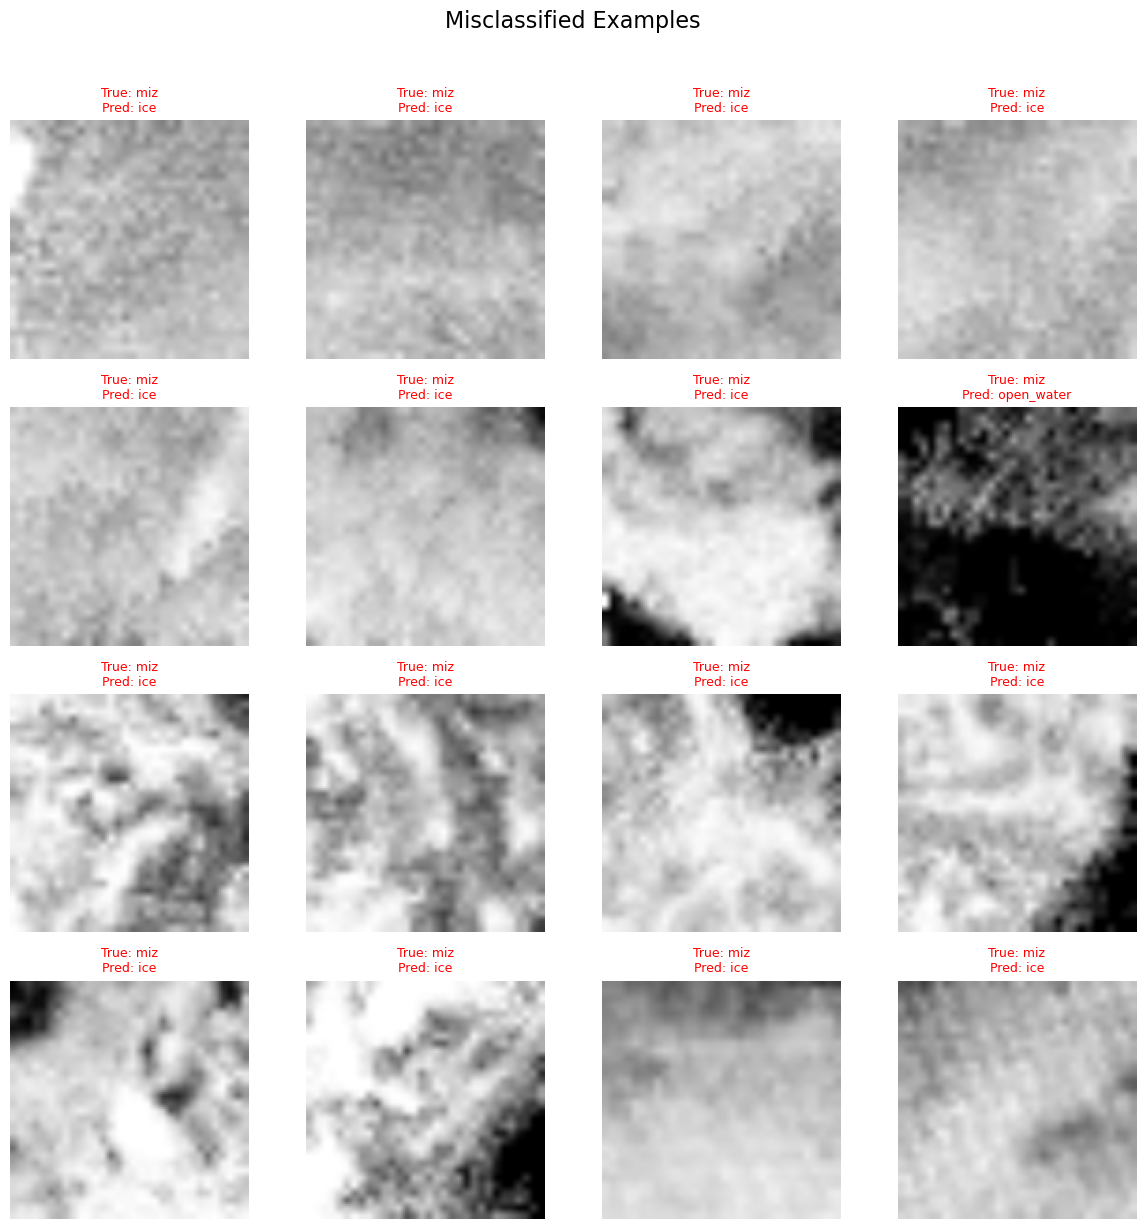


Look at these images carefully:
  - Are they genuinely ambiguous? (Hard even for a human?)
  - Do you see patterns in the mistakes?
  - MIZ images are often confused with ice or open_water
    because the marginal ice zone really is a transition region.


In [11]:
# Collect misclassified examples
misclassified_images = []
misclassified_true = []
misclassified_pred = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images_dev = images.to(device)
        outputs = model(images_dev)
        _, predicted = torch.max(outputs, 1)
        
        # Find misclassified in this batch
        wrong = predicted.cpu() != labels
        for i in range(len(labels)):
            if wrong[i]:
                misclassified_images.append(images[i])
                misclassified_true.append(labels[i].item())
                misclassified_pred.append(predicted[i].cpu().item())

print(f"Total misclassified: {len(misclassified_images)} out of {len(test_dataset)}")
print(f"Error rate: {100*len(misclassified_images)/len(test_dataset):.2f}%")

# Plot a grid of misclassified images
n_show = min(16, len(misclassified_images))
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
fig.suptitle('Misclassified Examples', fontsize=16, y=1.02)

for i, ax in enumerate(axes.flat):
    if i < n_show:
        img = misclassified_images[i].squeeze() * 0.5 + 0.5  # Undo normalisation
        ax.imshow(img, cmap='gray', vmin=0, vmax=1)
        true_name = class_names[misclassified_true[i]]
        pred_name = class_names[misclassified_pred[i]]
        ax.set_title(f'True: {true_name}\nPred: {pred_name}', fontsize=9, color='red')
    ax.axis('off')

plt.tight_layout()
plt.show()

print("\nLook at these images carefully:")
print("  - Are they genuinely ambiguous? (Hard even for a human?)")
print("  - Do you see patterns in the mistakes?")
print("  - MIZ images are often confused with ice or open_water")
print("    because the marginal ice zone really is a transition region.")

---
## 12. Distribution Shift — Does the Model Generalise Across Years?

This is a critical concept for any real-world application of machine learning.

Our model was trained on data from one time period (the training set). But the Arctic is changing rapidly — sea ice extent has been declining, ice thickness is decreasing, and the marginal ice zone is expanding. If the statistical properties of the sea ice change between years, our model may perform differently on data from other time periods.

This phenomenon is called **distribution shift** (or **dataset shift**, **domain shift**): the data the model encounters at deployment time comes from a different distribution than the training data.

We have two additional test sets to investigate this:
- **`test_2019`**: 1800 images from 2019 (600 per class)
- **`test_2024`**: 1800 images from 2024 (600 per class)

Let's see how our model performs on each.

In [12]:
# Load the additional test sets
test_2019_dataset = datasets.ImageFolder(root=data_dir + 'test_2019', transform=transform)
test_2024_dataset = datasets.ImageFolder(root=data_dir + 'test_2024', transform=transform)

test_2019_loader = DataLoader(test_2019_dataset, batch_size=64, shuffle=False)
test_2024_loader = DataLoader(test_2024_dataset, batch_size=64, shuffle=False)

print(f"Test 2019: {len(test_2019_dataset)} images")
print(f"Test 2024: {len(test_2024_dataset)} images")

# Evaluate on all three test sets
preds_2019, labels_2019, acc_2019, per_class_2019 = evaluate_model(
    model, test_2019_loader, class_names, device
)
preds_2024, labels_2024, acc_2024, per_class_2024 = evaluate_model(
    model, test_2024_loader, class_names, device
)

# Summary comparison
print("\n" + "=" * 65)
print("  ACCURACY COMPARISON ACROSS TEST SETS")
print("=" * 65)
print(f"\n{'Dataset':<18s} {'Overall':>9s} {'ice':>9s} {'miz':>9s} {'open_water':>12s}")
print("-" * 60)
print(f"{'Test (2023)':<18s} {test_acc:8.2f}% {test_per_class['ice']:8.2f}% "
      f"{test_per_class['miz']:8.2f}% {test_per_class['open_water']:8.2f}%")
print(f"{'Test 2019':<18s} {acc_2019:8.2f}% {per_class_2019['ice']:8.2f}% "
      f"{per_class_2019['miz']:8.2f}% {per_class_2019['open_water']:8.2f}%")
print(f"{'Test 2024':<18s} {acc_2024:8.2f}% {per_class_2024['ice']:8.2f}% "
      f"{per_class_2024['miz']:8.2f}% {per_class_2024['open_water']:8.2f}%")
print("=" * 65)

Test 2019: 1800 images
Test 2024: 1800 images

  ACCURACY COMPARISON ACROSS TEST SETS

Dataset              Overall       ice       miz   open_water
------------------------------------------------------------
Test (2023)           91.42%   100.00%    74.25%   100.00%
Test 2019             91.72%   100.00%    75.17%   100.00%
Test 2024             90.00%   100.00%    70.00%   100.00%


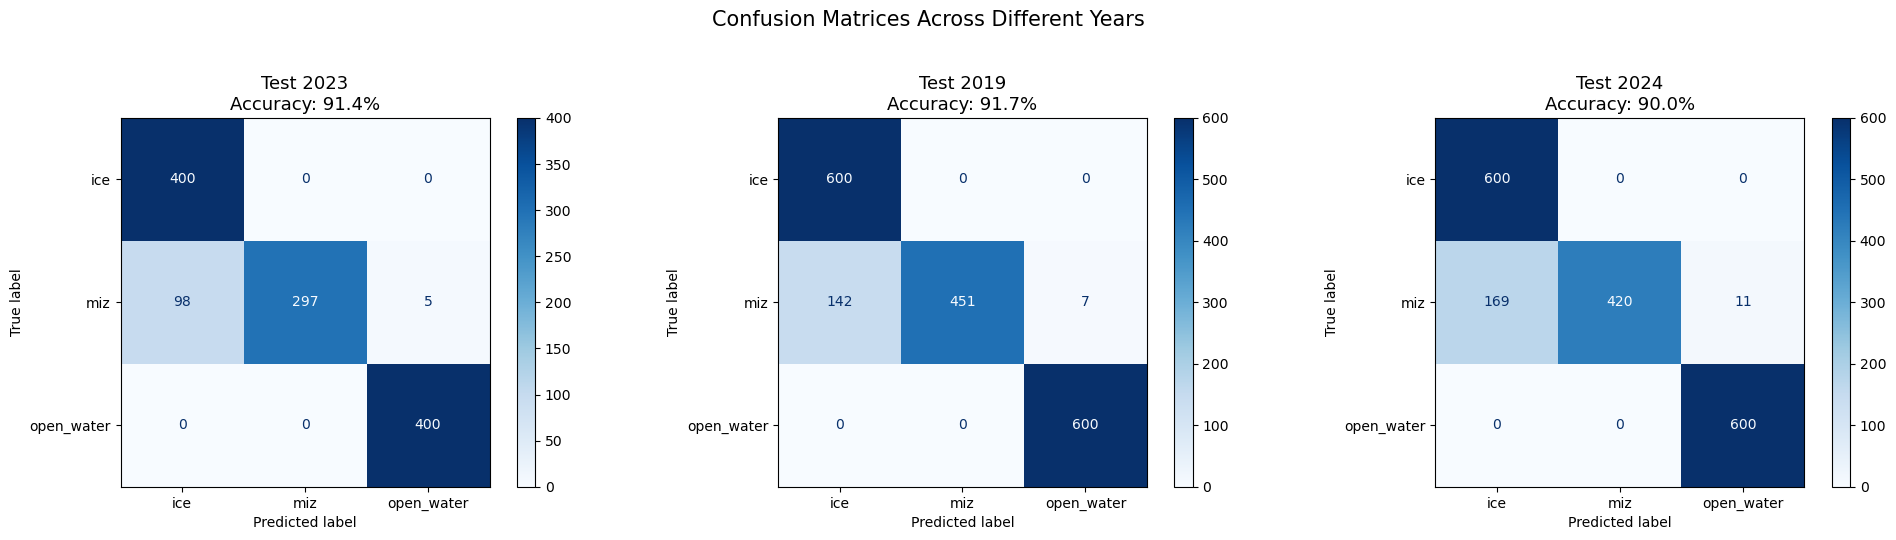

In [13]:
# Compare confusion matrices across all three test sets
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, (preds, labels, title) in zip(axes, [
    (test_preds, test_labels, 'Test 2023'),
    (preds_2019, labels_2019, 'Test 2019'),
    (preds_2024, labels_2024, 'Test 2024'),
]):
    cm = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    acc = 100.0 * (preds == labels).sum() / len(labels)
    ax.set_title(f'{title}\nAccuracy: {acc:.1f}%', fontsize=13)

plt.suptitle('Confusion Matrices Across Different Years', fontsize=15, y=1.05)
plt.tight_layout()
plt.show()

### Interpreting the distribution shift results

Compare the three confusion matrices carefully:

- **If accuracy is similar across all years**: The model has learned robust, generalisable features. The statistical properties of sea ice imagery are stable enough that training on one period transfers well to others.

- **If accuracy drops on 2019 or 2024**: This is **distribution shift** in action. Possible reasons include:
  - **Physical changes**: The Arctic sea ice is genuinely different in different years — thinner, more fragmented, different melt patterns
  - **Sensor differences**: Different satellite sensors or processing pipelines may produce subtly different images
  - **Seasonal timing**: If the test sets come from different months, ice conditions will be very different
  - **Climate trends**: The long-term trend of Arctic ice loss means 2024 ice looks different from training-period ice

- **If MIZ accuracy drops the most**: This is expected! The marginal ice zone is the most variable region — its characteristics change the most between years as the boundary between ice and ocean shifts.

**This is a real and important problem for Earth science applications of ML.** A model that works perfectly on your training period may fail when deployed on new data. This is why we always evaluate on truly independent test sets, and why understanding your data's temporal and spatial distribution is critical.

---
## 13. Visualise What the CNN Learned

One advantage of CNNs over black-box models is that we can actually *look at* what they learned. Let's visualise:

1. **First-layer convolutional filters**: These are the 3×3 patterns the network learned to detect
2. **Feature maps**: What the network "sees" when it processes an image from each class

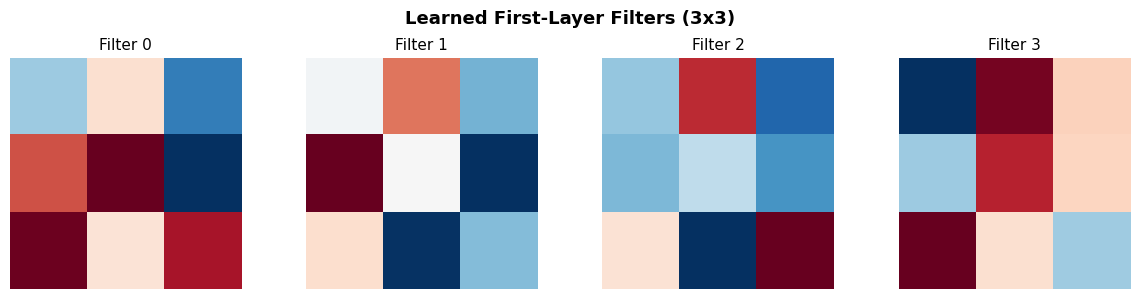

These 4 filters are all the model has to work with.
Compare with a deeper model — more filters = more features detected.


In [14]:
# Visualise the learned convolutional filters
filters = model.conv1.weight.data.cpu().numpy()
n_filters = filters.shape[0]

fig, axes = plt.subplots(1, n_filters, figsize=(3 * n_filters, 3))
if n_filters == 1:
    axes = [axes]

for i in range(n_filters):
    ax = axes[i]
    filt = filters[i, 0]  # shape: (3, 3)
    ax.imshow(filt, cmap='RdBu_r', interpolation='nearest')
    ax.set_title(f'Filter {i}', fontsize=11)
    ax.axis('off')

plt.suptitle('Learned First-Layer Filters (3x3)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"These {n_filters} filters are all the model has to work with.")
print("Compare with a deeper model — more filters = more features detected.")


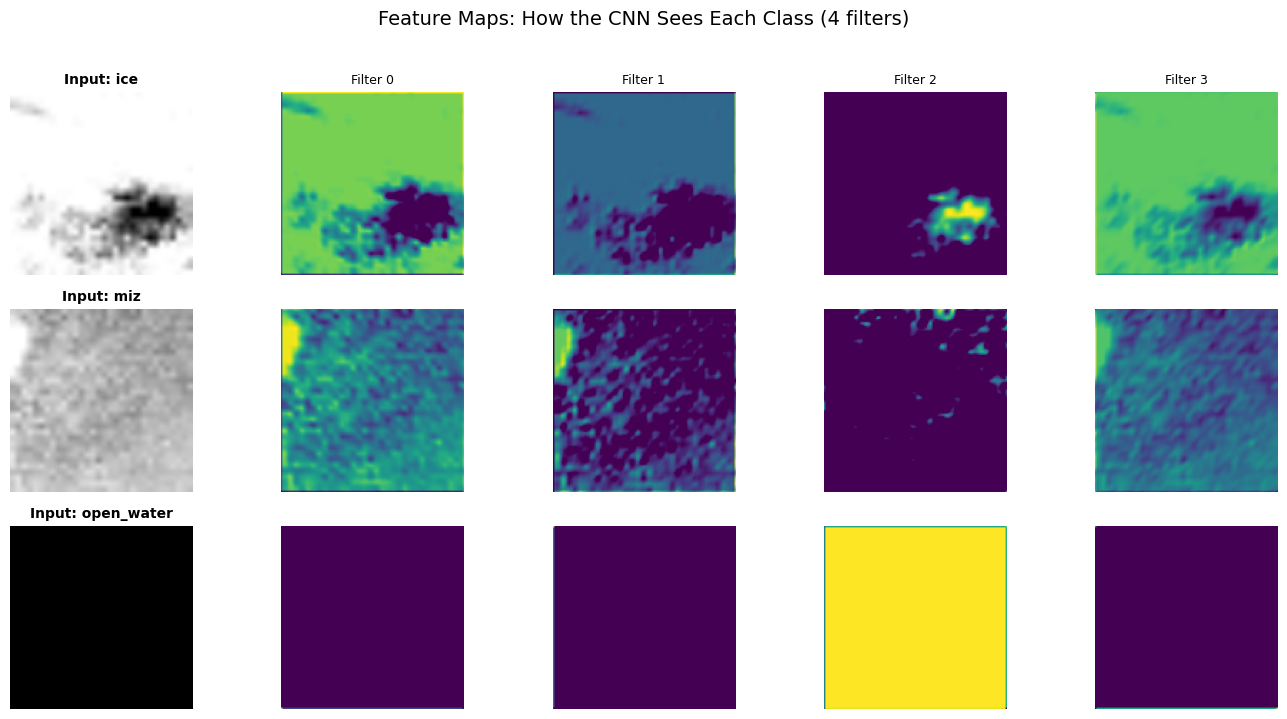

In [15]:
# Show feature maps from the first conv layer for one example from each class
fig, axes = plt.subplots(3, 5, figsize=(14, 7))

# Get one example from each class
example_images = {}
for images, labels in test_loader:
    for i in range(len(labels)):
        label = labels[i].item()
        if label not in example_images:
            example_images[label] = images[i:i+1]
        if len(example_images) == n_classes:
            break
    if len(example_images) == n_classes:
        break

model.eval()
for row, class_idx in enumerate(range(n_classes)):
    img_tensor = example_images[class_idx].to(device)
    
    # Get first conv layer output
    with torch.no_grad():
        feature_maps = model.relu(model.conv1(img_tensor))
    
    # Show original image
    img_display = example_images[class_idx].squeeze() * 0.5 + 0.5
    axes[row, 0].imshow(img_display, cmap='gray', vmin=0, vmax=1)
    axes[row, 0].set_title(f'Input: {class_names[class_idx]}', fontsize=10, fontweight='bold')
    axes[row, 0].axis('off')
    
    # Show all 4 feature maps
    for j in range(4):
        fmap = feature_maps[0, j].cpu().numpy()
        axes[row, j+1].imshow(fmap, cmap='viridis')
        if row == 0:
            axes[row, j+1].set_title(f'Filter {j}', fontsize=9)
        axes[row, j+1].axis('off')

plt.suptitle('Feature Maps: How the CNN Sees Each Class (4 filters)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


---
## 15. Discussion and Next Steps

### What did we learn from this simple model?

The single-layer CNN gives us a **baseline**. Look at the confusion matrix — which classes does it confuse? Almost certainly, `miz` is the hardest because it requires understanding texture, not just average brightness.

### Your turn: improve the model!

Try these modifications and see how accuracy changes. Edit the `SeaIceCNN` class above, restart the training, and compare:

**Level 1 — Add depth:**
```python
# Add a second conv layer after the first:
self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
# Don't forget another pool and to update the fc1 input size!
```

**Level 2 — Add more filters:**
```python
# Try 16 -> 32 -> 64 filters across three layers
self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
```

**Level 3 — Add regularisation:**
```python
# Add dropout before the final layer to prevent overfitting
self.dropout = nn.Dropout(0.5)
```

**Level 4 — Add batch normalisation:**
```python
self.bn1 = nn.BatchNorm2d(16)
# Use as: x = self.pool(self.relu(self.bn1(self.conv1(x))))
```

**Questions to think about:**
- How many layers do you need before accuracy plateaus?
- Does the model generalise better to 2019/2024 with more capacity, or worse?
- What is the minimum model that gets the `miz` class right?

In [28]:
# Final summary
print("\n" + "=" * 65)
print("       FINAL SUMMARY — CNN Sea Ice Classification")
print("=" * 65)
print(f"  Architecture:      1 conv layer, 4 filters, MaxPool(4)")
print(f"  Parameters:        {total_params:,}")
print(f"  Training epochs:   {n_epochs}")
print(f"  Training images:   {len(train_dataset)} ({n_per_class} per class)")
print(f"  Test images:       {len(test_dataset)}")
print(f"  Classes:           {class_names}")
print("=" * 65)
print("\nTip: try increasing n_per_class or adding more conv layers!")



       FINAL SUMMARY — CNN Sea Ice Classification
  Architecture:      1 conv layer, 4 filters, MaxPool(4)
  Parameters:        12,331
  Training epochs:   5
  Training images:   90 (30 per class)
  Test images:       1200
  Classes:           ['ice', 'miz', 'open_water']

Tip: try increasing n_per_class or adding more conv layers!
